# Lab 03: Is There a Planet in Your Light Curve?

**ASTR 457, Fall 2026 — posted Thu Sep 17, due Wed Sep 23 by Noon (fork → PR, as always)**

*Why this lab: transit fitting by maximum likelihood is how thousands of planets — including every temperate world around an M dwarf that David Charbonneau will talk about at the Sep 29 colloquium — were actually measured, and the gap between an error bar computed the lazy way and one computed honestly is exactly the gap between a claim that survives referees and one that doesn't.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `t_days`
(time from the start of a ~27-day TESS-style observing sector, 30-minute cadence, with a
~1-day data gap in the middle), `flux_rel` (relative flux, normalized near 1), and
`sigma_flux` (the per-point **white-noise** uncertainty). Your star is a nearby M dwarf
with a candidate transiting super-Earth. The light curve contains: the transit train,
slow instrumental systematics (drifts over days), and — as you will discover — noise
that is not entirely captured by `sigma_flux`. I know the true mid-transit time $t_0$,
period $P$, depth $\delta$, and duration $T$ for your dataset. You don't, you can't look
them up, and your classmates' planets are different from yours.

**How this is graded.** As always: on whether your answers are *right* and your
uncertainties are *honest*. Your reported depth and period are compared to your truth in
units of your own reported uncertainty. Anti-sandbagging cap: your $\sigma_\delta$ may
not exceed 3× a reference uncertainty I compute for your dataset — defensive error bars
lose points just like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants — and
document it in Part 4. You may be selected to defend this lab in person (the practice
round was Sep 15; the real ones use the same format).

## The transit model (given)

Use this five-parameter periodic trapezoid — the small-planet limit of Mandel & Agol
(2002), the same model from Tuesday's lecture. The parameters are
$\theta = (t_0, P, \delta, T, F_0)$: mid-transit time of the first transit, period,
depth, total duration, and out-of-transit baseline flux. Ingress and egress each span
20% of the duration.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def transit_model(t, t0, period, depth, duration, baseline, ingress_frac=0.2):
    """Periodic trapezoidal transit train."""
    ph = ((t - t0 + 0.5 * period) % period) - 0.5 * period
    half = duration / 2.
    ing = ingress_frac * duration
    f = np.ones_like(t)
    inside = np.abs(ph) < half
    full = np.abs(ph) < (half - ing)
    f[inside] = 1. - depth * np.clip((half - np.abs(ph[inside])) / ing, 0., 1.)
    f[full] = 1. - depth
    return baseline * f

NETID = 'siyaoxu2'  # <-- set this
d = np.genfromtxt(f'data/{NETID}.csv', delimiter=',', names=True, skip_header=1)
t, flux, sigma = d['t_days'], d['flux_rel'], d['sigma_flux']
print(f'{len(t)} points spanning {t[-1]:.1f} days; stated sigma = {sigma[0]*1e3:.2f} ppt')

1263 points spanning 27.4 days; stated sigma = 1.15 ppt


## Part 1: Find the planet (20%)

1. Plot the raw light curve. Identify the slow systematic trend and the transits.
2. **Detrend** the light curve. Be deliberate: state your method (median filter, spline,
   polynomial per segment — your choice), your smoothing scale, and *why that scale
   can't eat your transits*. Plot raw, trend, and detrended flux.
3. From the detrended curve, read off by eye: approximate $t_0$, $P$, depth, duration —
   your initial guesses for Part 2.
4. Compare the out-of-transit scatter of your detrended flux to the stated `sigma_flux`.
   Are they consistent? Say what you conclude (a sentence is fine — you'll need this
   observation in Parts 2 and 3).

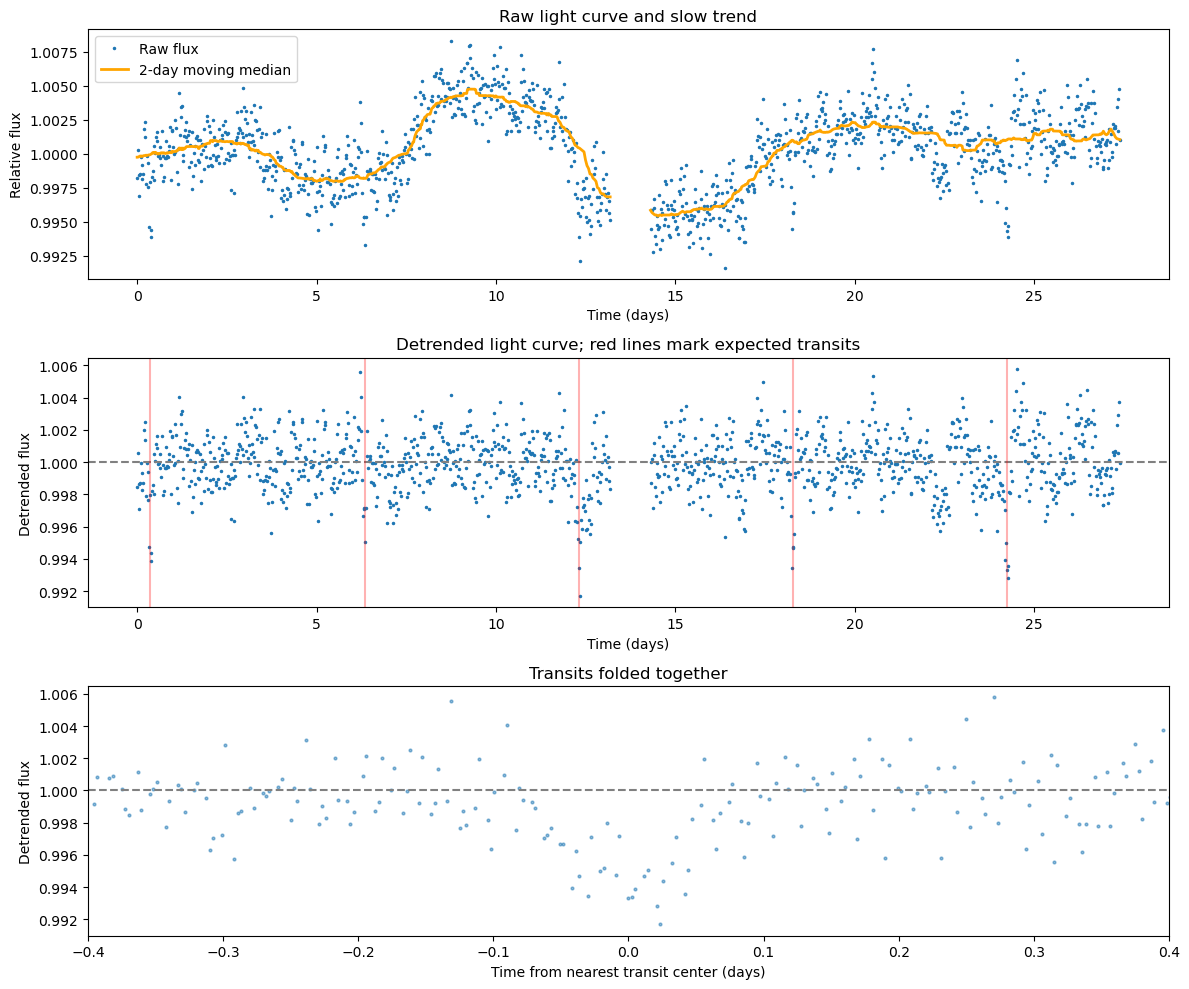

Out-of-transit scatter: 1.655 ppt
Stated uncertainty:    1.145 ppt
Scatter / uncertainty: 1.45


In [9]:
# Part 1: your work here
t0_guess = 0.37
P_guess = 5.97
depth_guess = 0.005
duration_guess = 0.20
baseline_guess = 1.0

phase_time = (t - t0_guess + P_guess / 2) % P_guess - P_guess / 2

out_of_transit = np.abs(phase_time) > 0.20


segments = np.split(
    np.arange(len(t)),
    np.where(np.diff(t) > 0.5)[0] + 1
)

trend = np.empty_like(flux)

for segment in segments:
    for i in segment:
        nearby = segment[
            (np.abs(t[segment] - t[i]) <= 1.0)
            & out_of_transit[segment]
        ]
        trend[i] = np.median(flux[nearby])


flux_detrended = flux / trend
sigma_detrended = sigma / trend


fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(t, flux, ".", ms=3, label="Raw flux")
for k, segment in enumerate(segments):
    axes[0].plot(
        t[segment], trend[segment], color="orange", lw=2,
        label="2-day moving median" if k == 0 else None
    )
axes[0].set_ylabel("Relative flux")
axes[0].set_xlabel("Time (days)")
axes[0].set_title("Raw light curve and slow trend")
axes[0].legend()

axes[1].plot(t, flux_detrended, ".", ms=3)
axes[1].axhline(1, color="gray", ls="--")
for center in np.arange(t0_guess, t.max(), P_guess):
    axes[1].axvline(center, color="red", alpha=0.3)
axes[1].set_ylabel("Detrended flux")
axes[1].set_xlabel("Time (days)")
axes[1].set_title("Detrended light curve; red lines mark expected transits")

axes[2].plot(phase_time, flux_detrended, ".", ms=4, alpha=0.5)
axes[2].axhline(1, color="gray", ls="--")
axes[2].set_xlim(-0.4, 0.4)
axes[2].set_ylabel("Detrended flux")
axes[2].set_xlabel("Time from nearest transit center (days)")
axes[2].set_title("Transits folded together")

plt.tight_layout()
plt.show()


scatter = np.std(flux_detrended[out_of_transit], ddof=1)
stated_sigma = np.median(sigma_detrended[out_of_transit])

print(f"Out-of-transit scatter: {scatter * 1000:.3f} ppt")
print(f"Stated uncertainty:    {stated_sigma * 1000:.3f} ppt")
print(f"Scatter / uncertainty: {scatter / stated_sigma:.2f}")

theta0 = [
    t0_guess, P_guess, depth_guess,
    duration_guess, baseline_guess
]

**ANSWERS (initial guesses + scatter check):**

*your answers go here*

## Part 2: The measurement you'd publish (40%)

1. Write the Gaussian log-likelihood for the transit model and maximize it
   (`scipy.optimize.minimize`; Nelder-Mead first, as in lecture). Fit all five
   parameters. Plot the phase-folded data with your best-fit model, and the residuals.
2. Estimate uncertainties **two ways**:
   - from the curvature of the log-likelihood at the maximum (the inverse Hessian —
     lecture method), and
   - by **bootstrap** — and think about *what* you resample: if you resample individual
     points, what are you assuming about the noise? A block bootstrap (resample
     contiguous chunks of residuals, e.g. 1-day blocks) makes a different assumption.
     Do both point-wise and block versions and compare.
3. The three uncertainty estimates for the depth will not all agree. Explain the pattern
   using your Part 1 scatter observation. Which noise property do the Hessian and the
   point-wise bootstrap both assume that your residuals violate? Demonstrate that
   violation with a plot or a number (hint: bin your residuals in ~5-hour bins and
   compare the binned scatter to what independent noise predicts).
4. **Commit to final answers**: $\delta \pm \sigma_\delta$, $P \pm \sigma_P$,
   $t_0 \pm \sigma_{t_0}$, and justify which uncertainty estimate you adopted.

In [10]:
# Part 2: your work here
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

y = np.asarray(flux_detrended)
s = np.asarray(sigma_detrended)

origin = np.asarray(theta0, dtype=float)

scale = np.array([0.05, 0.01, 0.002, 0.10, 0.002])


def negative_log_likelihood(z, observed):
    t0, period, depth, duration, baseline = origin + scale * z

    valid = (
        0 < t0 < 1
        and 5.7 < period < 6.2
        and 0 < depth < 0.03
        and 0.03 < duration < 0.5
        and 0.97 < baseline < 1.03
    )

    if not valid:
        return 1e100

    model = transit_model(
        t, t0, period, depth, duration, baseline
    )

    return 0.5 * np.sum(
        ((observed - model) / s)**2
        + np.log(2 * np.pi * s**2)
    )


def run_nm(observed, start, width=0.2):
    simplex = np.vstack([
        start,
        start + width * np.eye(5)
    ])

    return minimize(
        negative_log_likelihood,
        start,
        args=(observed,),
        method="Nelder-Mead",
        options={
            "maxiter": 4000,
            "xatol": 1e-6,
            "fatol": 1e-7,
            "initial_simplex": simplex
        }
    )


trials = []

for duration_start in [0.12, 0.18, 0.24]:
    start = origin.copy()
    start[3] = duration_start

    fit = run_nm(y, (start - origin) / scale)

    if fit.success:
        trials.append(fit)

if not trials:
    raise RuntimeError("The transit fit did not converge.")

best = min(trials, key=lambda fit: fit.fun)

for _ in range(3):
    trial = run_nm(y, best.x)

    if trial.success and trial.fun < best.fun:
        best = trial

z_best = best.x
theta_best = origin + scale * z_best

model_best = transit_model(t, *theta_best)
residuals = y - model_best

names = [
    "t0 (days)",
    "P (days)",
    "depth (relative flux)",
    "T (days)",
    "baseline"
]

for name, value in zip(names, theta_best):
    print(f"{name:23s}: {value:.8f}")

chi2_red = np.sum((residuals / s)**2) / (len(t) - 5)
print(f"Reduced chi-square = {chi2_red:.3f}")

t0 (days)              : 0.35760414
P (days)               : 5.97280276
depth (relative flux)  : 0.00512202
T (days)               : 0.13494064
baseline               : 1.00000226
Reduced chi-square = 2.125


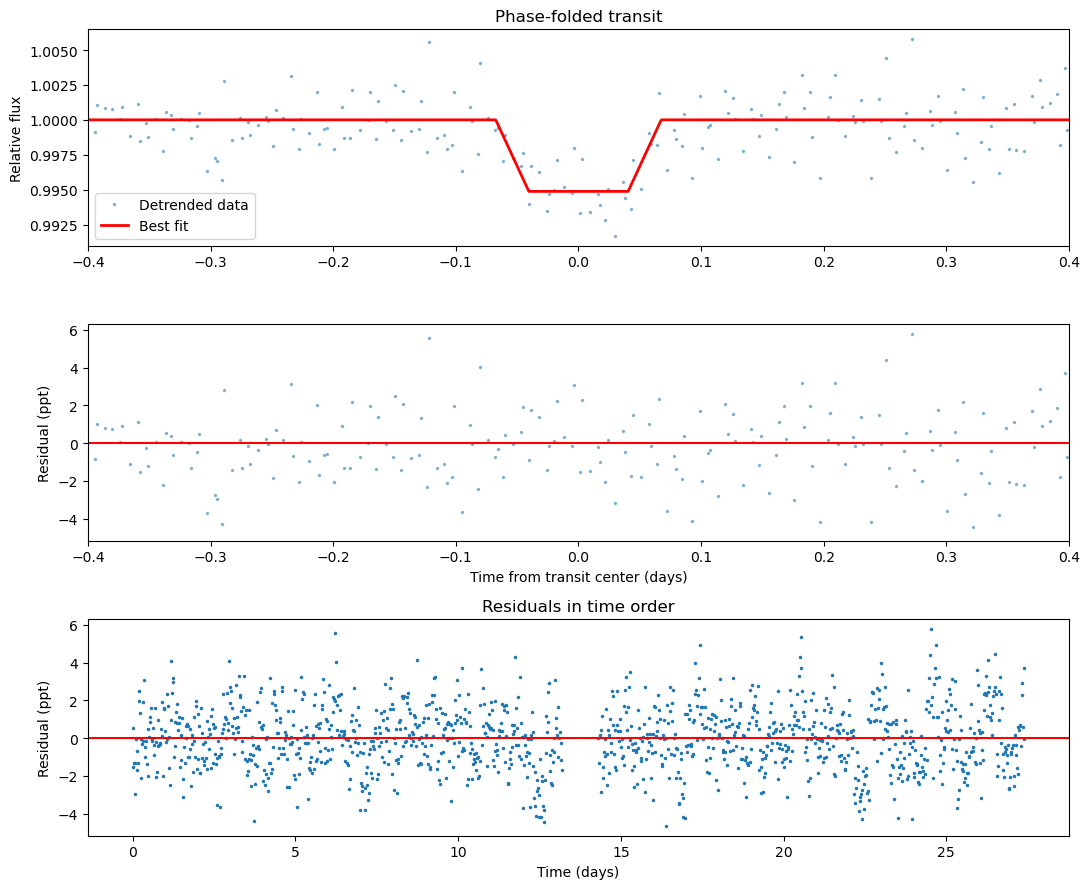

In [11]:
t0_fit, P_fit, depth_fit, T_fit, F0_fit = theta_best

phase_fit = (
    (t - t0_fit + P_fit / 2) % P_fit
    - P_fit / 2
)

grid = np.linspace(-0.4, 0.4, 1200)

fig, ax = plt.subplots(3, 1, figsize=(11, 9))

ax[0].plot(
    phase_fit, y, ".",
    ms=3, alpha=0.45,
    label="Detrended data"
)

ax[0].plot(
    grid,
    transit_model(t0_fit + grid, *theta_best),
    "r-", lw=2,
    label="Best fit"
)

ax[0].set(
    xlim=(-0.4, 0.4),
    ylabel="Relative flux",
    title="Phase-folded transit"
)
ax[0].legend()

ax[1].plot(
    phase_fit, residuals * 1000,
    ".", ms=3, alpha=0.45
)

ax[1].axhline(0, color="r")

ax[1].set(
    xlim=(-0.4, 0.4),
    xlabel="Time from transit center (days)",
    ylabel="Residual (ppt)"
)

ax[2].plot(t, residuals * 1000, ".", ms=3)
ax[2].axhline(0, color="r")

ax[2].set(
    xlabel="Time (days)",
    ylabel="Residual (ppt)",
    title="Residuals in time order"
)

plt.tight_layout()
plt.show()

In [12]:
def numerical_hessian(function, z, h):
    n = len(z)
    H = np.zeros((n, n))
    step = np.eye(n) * h
    f0 = function(z)

    for i in range(n):
        H[i, i] = (
            function(z + step[i])
            - 2 * f0
            + function(z - step[i])
        ) / h**2

        for j in range(i):
            H[i, j] = H[j, i] = (
                function(z + step[i] + step[j])
                - function(z + step[i] - step[j])
                - function(z - step[i] + step[j])
                + function(z - step[i] - step[j])
            ) / (4 * h**2)

    return H


hessian_errors = {}

for h in [0.03, 0.01, 0.003]:
    H = numerical_hessian(
        lambda z: negative_log_likelihood(z, y),
        z_best,
        h
    )

    if np.min(np.linalg.eigvalsh(H)) <= 0:
        raise RuntimeError(
            "Hessian is not positive definite."
        )

    covariance_z = np.linalg.inv(H)

    errors = scale * np.sqrt(np.diag(covariance_z))
    hessian_errors[h] = errors

    print(
        f"h = {h:.3f}: "
        f"sigma_depth = {errors[2] * 1000:.3f} ppt, "
        f"sigma_P = {errors[1]:.6f} d, "
        f"sigma_t0 = {errors[0]:.6f} d"
    )

sigma_hessian = hessian_errors[0.01]

h = 0.030: sigma_depth = 0.251 ppt, sigma_P = 0.000844 d, sigma_t0 = 0.002500 d
h = 0.010: sigma_depth = 0.248 ppt, sigma_P = 0.000455 d, sigma_t0 = 0.001635 d
h = 0.003: sigma_depth = 0.241 ppt, sigma_P = 0.000259 d, sigma_t0 = 0.001008 d


In [13]:
rng = np.random.default_rng(457)
B = 600

segments = np.split(
    np.arange(len(t)),
    np.where(np.diff(t) > 0.5)[0] + 1
)

cadence = np.median(np.diff(t))

block_length = int(round(1.0 / cadence))

standardized_residuals = residuals / s
standardized_residuals -= np.mean(standardized_residuals)

block_pool = np.array([
    standardized_residuals[
        segment[j:j + block_length]
    ]
    for segment in segments
    for j in range(len(segment) - block_length + 1)
])


def draw_residuals(kind):
    if kind == "point":
        return rng.choice(
            standardized_residuals,
            size=len(t),
            replace=True
        )

    drawn = np.empty(len(t))

    for segment in segments:
        count = int(
            np.ceil(len(segment) / block_length)
        )

        chosen = rng.integers(
            0, len(block_pool), size=count
        )

        drawn[segment] = (
            block_pool[chosen].ravel()[:len(segment)]
        )

    return drawn


def bootstrap(kind):
    samples = []

    for b in range(B):
        simulated = (
            model_best + s * draw_residuals(kind)
        )

        fitted = run_nm(simulated, z_best)

        restarted = run_nm(
            simulated, fitted.x, width=0.1
        )

        candidates = [
            result
            for result in (fitted, restarted)
            if result.success and np.isfinite(result.fun)
        ]

        if not candidates:
            raise RuntimeError(
                f"{kind} bootstrap replicate {b} failed."
            )

        fitted = min(
            candidates,
            key=lambda result: result.fun
        )

        samples.append(
            origin + scale * fitted.x
        )

        if (b + 1) % 100 == 0:
            print(
                f"{kind}: {b + 1}/{B}",
                flush=True
            )

    return np.array(samples)


point_samples = bootstrap("point")
block_samples = bootstrap("block")

sigma_point = np.std(
    point_samples, axis=0, ddof=1
)

sigma_block = np.std(
    block_samples, axis=0, ddof=1
)

print(
    f"\nBlock length: {block_length} points, "
    f"about {block_length * cadence:.2f} days"
)

print(
    "\nMethod                    "
    "sigma_depth (ppt)   sigma_P (d)   sigma_t0 (d)"
)

for label, errors in [
    ("Hessian (finite step)", sigma_hessian),
    ("Point bootstrap", sigma_point),
    ("Block bootstrap", sigma_block)
]:
    print(
        f"{label:25s} "
        f"{errors[2] * 1000:9.3f}          "
        f"{errors[1]:.6f}      "
        f"{errors[0]:.6f}"
    )

point: 100/600
point: 200/600
point: 300/600
point: 400/600
point: 500/600
point: 600/600
block: 100/600
block: 200/600
block: 300/600
block: 400/600
block: 500/600
block: 600/600

Block length: 48 points, about 1.00 days

Method                    sigma_depth (ppt)   sigma_P (d)   sigma_t0 (d)
Hessian (finite step)         0.248          0.000455      0.001635
Point bootstrap               0.356          0.001878      0.004546
Block bootstrap               0.504          0.001809      0.004565


Points per bin: 10; about 5.0 hours
Independent-noise prediction: 0.527 ppt
Observed binned scatter: 0.982 ppt
Observed / predicted: 1.86


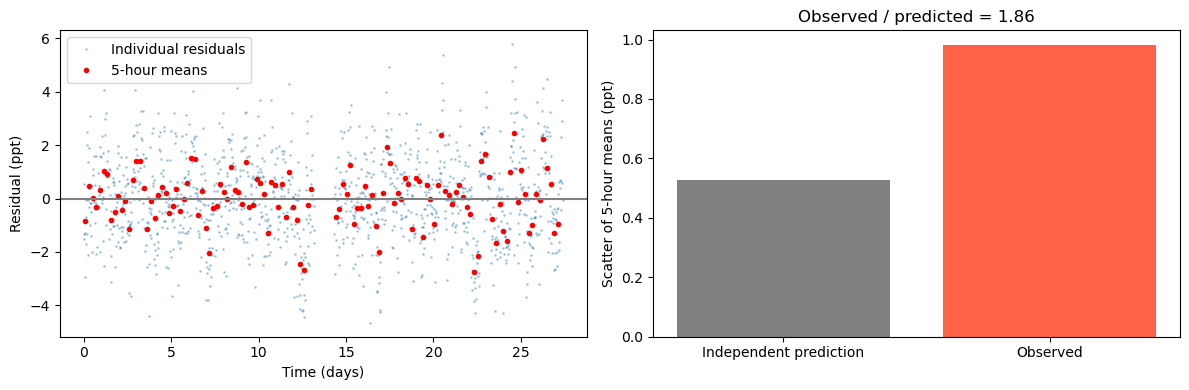

In [14]:
n_bin = int(round((5 / 24) / cadence))

bin_times = []
bin_means = []

for segment in segments:
    for j in range(
        0, len(segment) - n_bin + 1, n_bin
    ):
        indices = segment[j:j + n_bin]

        bin_times.append(np.mean(t[indices]))
        bin_means.append(
            np.mean(residuals[indices])
        )

bin_times = np.asarray(bin_times)
bin_means = np.asarray(bin_means)

unbinned_scatter = np.std(
    residuals, ddof=1
)

predicted_scatter = (
    unbinned_scatter / np.sqrt(n_bin)
)

actual_scatter = np.std(
    bin_means, ddof=1
)

beta = actual_scatter / predicted_scatter

print(
    f"Points per bin: {n_bin}; "
    f"about {n_bin * cadence * 24:.1f} hours"
)

print(
    "Independent-noise prediction: "
    f"{predicted_scatter * 1000:.3f} ppt"
)

print(
    "Observed binned scatter: "
    f"{actual_scatter * 1000:.3f} ppt"
)

print(f"Observed / predicted: {beta:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(
    t, residuals * 1000,
    ".", ms=2, alpha=0.3,
    label="Individual residuals"
)

ax[0].plot(
    bin_times, bin_means * 1000,
    "o", ms=3, color="red",
    label="5-hour means"
)

ax[0].axhline(0, color="gray")

ax[0].set(
    xlabel="Time (days)",
    ylabel="Residual (ppt)"
)
ax[0].legend()

ax[1].bar(
    ["Independent prediction", "Observed"],
    [
        predicted_scatter * 1000,
        actual_scatter * 1000
    ],
    color=["gray", "tomato"]
)

ax[1].set(
    ylabel="Scatter of 5-hour means (ppt)",
    title=f"Observed / predicted = {beta:.2f}"
)

plt.tight_layout()
plt.show()

In [15]:
print(
    "FINAL ANSWER "
    "(block-bootstrap standard deviations):\n"
)

print(
    f"depth = {depth_fit * 1000:.2f} "
    f"+/- {sigma_block[2] * 1000:.2f} ppt"
)

print(
    f"P = {P_fit:.4f} "
    f"+/- {sigma_block[1]:.4f} days"
)

print(
    f"t0 = {t0_fit:.4f} "
    f"+/- {sigma_block[0]:.4f} days"
)

print(f"\nDuration = {T_fit * 24:.2f} hours")
print(f"Baseline = {F0_fit:.6f}")

FINAL ANSWER (block-bootstrap standard deviations):

depth = 5.12 +/- 0.50 ppt
P = 5.9728 +/- 0.0018 days
t0 = 0.3576 +/- 0.0046 days

Duration = 3.24 hours
Baseline = 1.000002


**FINAL ANSWER:** $\delta = $ 5.12 $\pm$ 0.50 ppt, $P = $ 5.9728 $\pm$ 0.0018 d, $t_0 = $ 0.3576 $\pm$ 0.0046 d

**Which uncertainty and why (a short paragraph):**

I adopted the standard deviations from the 1 day block bootstrap because the residuals show time-correlated noise. The scatter after averaging residuals in 5 hour bins is 0.982 ppt, about 1.86 times the independent noise prediction of 0.527 ppt. Point wise bootstrap breaks these time correlations, while block bootstrap preserves them within each block. The depth uncertainties are approximately 0.248 ppt from the finite step Hessian, 0.356 ppt from point wise bootstrap, and 0.504 ppt from block bootstrap. The Hessian is also sensitive to the trapezoid model’s corners. These final uncertainties assume the Part 1 trend is fixed and use a 1 day block length.

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis
of this exact problem, produced by an AI assistant. It runs top to bottom without
errors, the phase-folded plot looks professional, and the prose is fluent. It is also
wrong — in at least **three** distinct, substantive ways (cosmetic nitpicks don't
count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset — show, with a number or a
   plot, what the error does to the inference. "This is bad practice" is not a
   demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

You've done this once before, on Lab 01. Notice how much faster you are at it now —
that speed is the skill this course is building.

**REFEREE REPORT:**

Flaw 1: The detrending removes part of the transit signal.

The AI solution uses a 6-hour median filter without masking transits. This window is too close to the approximately 3.24-hour transit duration, so the estimated trend can follow and remove part of the dip. On my dataset, the AI pipeline measures a depth of 3.331 ppt, compared with 5.122 ppt in Part 2, about 35% smaller. In a controlled test using a noiseless transit with a known input depth of 5.122 ppt, the same filter reduces the template-fit depth to 4.828 ppt. This confirms that the filter itself can weaken the signal. The correct treatment is to mask transits when estimating the trend, use a longer smoothing window, and handle the observation gap separately.

Flaw 2: The depth uncertainty ignores uncertainty in the other parameters.

The AI solution calculates curvature only along the depth direction while holding the other four parameters fixed. Their best-fit values are not known exactly, and their uncertainties can affect the depth measurement. Keeping the AI-detrended data and noise scale unchanged, I compared this conditional error with a profile likelihood that refits the other four parameters at each depth. The conditional error is approximately 0.299 ppt. After refining the fit, the profile interval is 3.020–3.653 ppt around a depth of 3.329 ppt, giving errors of −0.309/+0.324 ppt. The underestimate is modest here but measurable. The correct treatment is to account for parameter coupling using a valid full inverse Hessian or profile likelihood, and to refit all parameters during bootstrap. This profile comparison still assumes independent Gaussian noise.

Flaw 3: Reduced chi-squared near one does not validate the noise model.

The AI solution estimates noise using the standard deviation of the same detrended light curve, then claims that reduced chi-squared near one confirms reliable uncertainties. However, using this noise estimate, even a flat model gives reduced chi-squared (N/(N-1)=1.0008) by construction. Therefore, the AI transit fit’s value of 0.907 does not validate its noise assumptions. Residual binning also contradicts the independent-noise prediction: the AI residuals have a 5-hour scatter of 0.328 ppt versus a prediction of 0.427 ppt. With the protected detrending in Part 2, the observed scatter is 0.982 ppt versus 0.527 ppt predicted. Noise amplitude and time correlations must be checked separately. A suitable correction is to use a correlated-noise model or block bootstrap that preserves local correlations and refits all five parameters.

AI depth: 3.331 +/- 0.299 ppt
Part 2 depth: 5.122 ppt
AI depth is 35.0% smaller than Part 2.

Noiseless input depth: 5.122 ppt
After 6-hour filter: 4.828 ppt
Noiseless depth loss: 5.7%


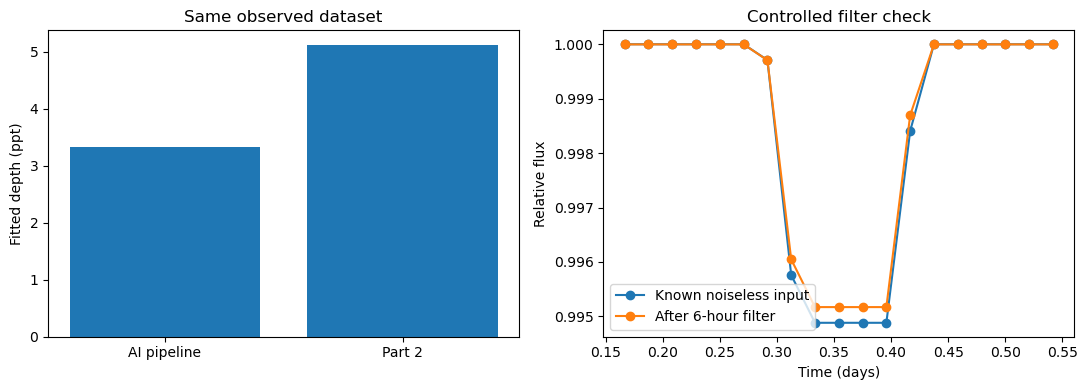

In [16]:
# Part 3: demonstrations here
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter
from scipy.optimize import minimize

ai_cadence = np.median(np.diff(t))
ai_window = max(3, int(round((6 / 24) / ai_cadence)))

ai_trend = median_filter(flux, size=ai_window)
ai_flux = flux - ai_trend + 1.0
ai_sigma = np.std(ai_flux)


def ai_nll(th, observed):
    model = transit_model(t, *th)

    return 0.5 * np.sum(
        ((observed - model) / ai_sigma)**2
    )


ai_P_alert = 5.97
ai_t0_alert = 6.3

ai_depth_guess = 1.0 - np.sort(ai_flux)[20]

ai_p0 = [
    ai_t0_alert,
    ai_P_alert,
    min(ai_depth_guess, 0.008),
    2.5 / 24,
    1.0
]

ai_best = None

for dp in (0.998, 1.0, 1.002):
    for dt0 in (-0.1, -0.05, 0.0, 0.05, 0.1):
        start = [
            ai_p0[0] + dt0,
            ai_p0[1] * dp,
            ai_p0[2],
            ai_p0[3],
            ai_p0[4]
        ]

        result = minimize(
            ai_nll,
            start,
            args=(ai_flux,),
            method="Nelder-Mead",
            options={"maxiter": 20000}
        )

        if ai_best is None or result.fun < ai_best.fun:
            ai_best = result

if not ai_best.success:
    raise RuntimeError("AI fit did not converge.")

ai_theta = ai_best.x
ai_residuals = ai_flux - transit_model(t, *ai_theta)

ai_h = ai_theta[2] * 1e-3

ai_plus = ai_theta.copy()
ai_minus = ai_theta.copy()

ai_plus[2] += ai_h
ai_minus[2] -= ai_h

ai_curvature = (
    ai_nll(ai_plus, ai_flux)
    - 2 * ai_nll(ai_theta, ai_flux)
    + ai_nll(ai_minus, ai_flux)
) / ai_h**2

ai_conditional_original = 1 / np.sqrt(ai_curvature)

print(
    f"AI depth: {ai_theta[2] * 1000:.3f} "
    f"+/- {ai_conditional_original * 1000:.3f} ppt"
)

print(f"Part 2 depth: {theta_best[2] * 1000:.3f} ppt")

print(
    "AI depth is "
    f"{100 * (1 - ai_theta[2] / theta_best[2]):.1f}% "
    "smaller than Part 2."
)

test_pure = transit_model(t, *theta_best)

test_filtered = (
    test_pure
    - median_filter(test_pure, size=ai_window)
    + 1.0
)

test_shape = (
    (theta_best[4] - test_pure)
    / (theta_best[4] * theta_best[2])
)

test_X = np.column_stack([
    np.ones(len(t)),
    test_shape
])

test_b, test_c = np.linalg.lstsq(
    test_X,
    test_filtered,
    rcond=None
)[0]

test_recovered_depth = -test_c / test_b

print(
    f"\nNoiseless input depth: "
    f"{theta_best[2] * 1000:.3f} ppt"
)

print(
    f"After 6-hour filter: "
    f"{test_recovered_depth * 1000:.3f} ppt"
)

print(
    "Noiseless depth loss: "
    f"{100 * (1 - test_recovered_depth / theta_best[2]):.1f}%"
)


fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].bar(
    ["AI pipeline", "Part 2"],
    [ai_theta[2] * 1000, theta_best[2] * 1000]
)

ax[0].set(
    ylabel="Fitted depth (ppt)",
    title="Same observed dataset"
)

test_use = np.abs(t - theta_best[0]) < 0.2

ax[1].plot(
    t[test_use],
    test_pure[test_use],
    "o-",
    label="Known noiseless input"
)

ax[1].plot(
    t[test_use],
    test_filtered[test_use],
    "o-",
    label="After 6-hour filter"
)

ax[1].set(
    xlabel="Time (days)",
    ylabel="Relative flux",
    title="Controlled filter check"
)

ax[1].legend()
plt.tight_layout()
plt.show()

Refined AI depth: 3.329 ppt
Fixed-other-parameters error: 0.299 ppt
Profile interval: [3.020, 3.653] ppt
Profile errors: -0.309/+0.324 ppt


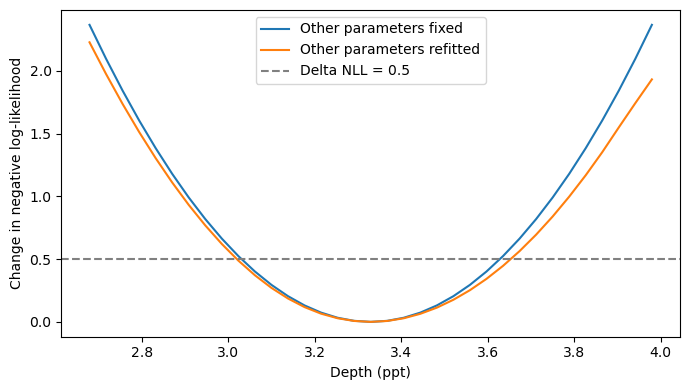

In [17]:
from scipy.optimize import brentq

pr_origin = ai_theta.copy()

pr_origin[0] %= pr_origin[1]

pr_scale = np.array([0.05, 0.01, 0.002, 0.1, 0.002])


def pr_nll(z):
    th = pr_origin + pr_scale * z

    valid = (
        0 < th[0] < 1
        and 5.7 < th[1] < 6.2
        and 0 < th[2] < 0.03
        and 0.03 < th[3] < 0.5
        and 0.97 < th[4] < 1.03
    )

    if not valid:
        return 1e100

    return ai_nll(th, ai_flux)


def pr_minimize(function, start, width=0.2):
    n = len(start)

    simplex = np.vstack([
        start,
        start + width * np.eye(n)
    ])

    return minimize(
        function,
        start,
        method="Nelder-Mead",
        options={
            "maxiter": 5000,
            "xatol": 1e-8,
            "fatol": 1e-9,
            "initial_simplex": simplex
        }
    )


pr_best = pr_minimize(pr_nll, np.zeros(5))

for _ in range(3):
    candidate = pr_minimize(pr_nll, pr_best.x)

    if candidate.success and candidate.fun < pr_best.fun:
        pr_best = candidate

if not pr_best.success:
    raise RuntimeError("Refined likelihood fit failed.")

pr_z = pr_best.x
pr_theta = pr_origin + pr_scale * pr_z

pr_free = np.array([0, 1, 3, 4])


def profile_nll(depth):
    def objective(v):
        z = pr_z.copy()

        z[2] = (depth - pr_origin[2]) / pr_scale[2]

        z[pr_free] = v

        return pr_nll(z)

    first = pr_minimize(
        objective,
        pr_z[pr_free]
    )

    second = pr_minimize(
        objective,
        first.x,
        width=0.1
    )

    converged = [
        result
        for result in (first, second)
        if result.success
    ]

    if not converged:
        raise RuntimeError("Profile fit failed.")

    return min(result.fun for result in converged)


pr_target = pr_best.fun + 0.5

pr_low = brentq(
    lambda depth: profile_nll(depth) - pr_target,
    pr_theta[2] - 0.002,
    pr_theta[2],
    xtol=1e-10
)

pr_high = brentq(
    lambda depth: profile_nll(depth) - pr_target,
    pr_theta[2],
    pr_theta[2] + 0.002,
    xtol=1e-10
)

pr_shape = (
    (pr_theta[4] - transit_model(t, *pr_theta))
    / (pr_theta[4] * pr_theta[2])
)

pr_conditional = ai_sigma / (
    pr_theta[4] * np.sqrt(np.sum(pr_shape**2))
)

print(f"Refined AI depth: {pr_theta[2] * 1000:.3f} ppt")

print(
    "Fixed-other-parameters error: "
    f"{pr_conditional * 1000:.3f} ppt"
)

print(
    f"Profile interval: "
    f"[{pr_low * 1000:.3f}, {pr_high * 1000:.3f}] ppt"
)

print(
    "Profile errors: "
    f"-{(pr_theta[2] - pr_low) * 1000:.3f}"
    f"/+{(pr_high - pr_theta[2]) * 1000:.3f} ppt"
)


pr_depths = np.linspace(
    pr_theta[2] - 0.00065,
    pr_theta[2] + 0.00065,
    35
)

pr_profile = np.array([
    profile_nll(depth)
    for depth in pr_depths
]) - pr_best.fun

pr_fixed = []

for depth in pr_depths:
    th = pr_theta.copy()
    th[2] = depth

    pr_fixed.append(
        ai_nll(th, ai_flux) - pr_best.fun
    )

plt.figure(figsize=(7, 4))

plt.plot(
    pr_depths * 1000,
    pr_fixed,
    label="Other parameters fixed"
)

plt.plot(
    pr_depths * 1000,
    pr_profile,
    label="Other parameters refitted"
)

plt.axhline(
    0.5,
    color="gray",
    linestyle="--",
    label="Delta NLL = 0.5"
)

plt.xlabel("Depth (ppt)")
plt.ylabel("Change in negative log-likelihood")
plt.legend()
plt.tight_layout()
plt.show()

AI transit reduced chi-square: 0.907
Flat-model reduced chi-square: 1.0008
N/(N-1), by construction: 1.0008

AI residuals:
  Predicted = 0.427 ppt
  Observed  = 0.328 ppt
  Ratio     = 0.77

Part 2 residuals:
  Predicted = 0.527 ppt
  Observed  = 0.982 ppt
  Ratio     = 1.86


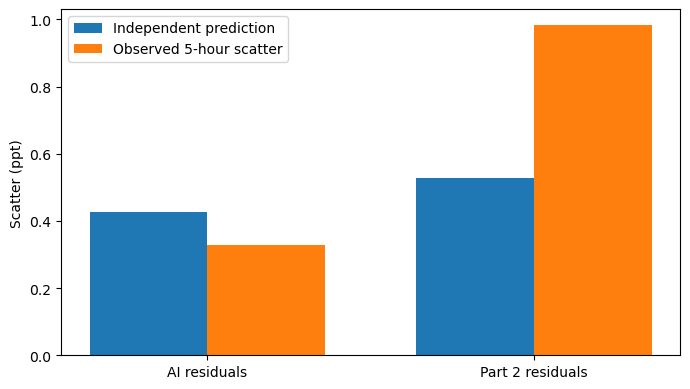

In [18]:

ai_chi2_red = (
    2 * ai_best.fun / (len(t) - 5)
)

ai_flat_chi2_red = np.sum(
    ((ai_flux - np.mean(ai_flux)) / ai_sigma)**2
) / (len(t) - 1)

print(
    f"AI transit reduced chi-square: "
    f"{ai_chi2_red:.3f}"
)

print(
    f"Flat-model reduced chi-square: "
    f"{ai_flat_chi2_red:.4f}"
)

print(
    f"N/(N-1), by construction: "
    f"{len(t) / (len(t) - 1):.4f}"
)

check_segments = np.split(
    np.arange(len(t)),
    np.where(np.diff(t) > 0.5)[0] + 1
)

check_n = int(round(
    (5 / 24) / np.median(np.diff(t))
))

part2_residuals = (
    flux_detrended - transit_model(t, *theta_best)
)

check_rows = []

for label, rr in [
    ("AI residuals", ai_residuals),
    ("Part 2 residuals", part2_residuals)
]:
    means = np.array([
        np.mean(rr[segment[j:j + check_n]])
        for segment in check_segments
        for j in range(
            0,
            len(segment) - check_n + 1,
            check_n
        )
    ])

    predicted = (
        np.std(rr, ddof=1) / np.sqrt(check_n)
    )

    observed = np.std(means, ddof=1)

    check_rows.append([
        predicted * 1000,
        observed * 1000
    ])

    print(
        f"\n{label}:"
        f"\n  Predicted = {predicted * 1000:.3f} ppt"
        f"\n  Observed  = {observed * 1000:.3f} ppt"
        f"\n  Ratio     = {observed / predicted:.2f}"
    )

check_rows = np.array(check_rows)
xx = np.arange(2)

plt.figure(figsize=(7, 4))

plt.bar(
    xx - 0.18,
    check_rows[:, 0],
    width=0.36,
    label="Independent prediction"
)

plt.bar(
    xx + 0.18,
    check_rows[:, 1],
    width=0.36,
    label="Observed 5-hour scatter"
)

plt.xticks(
    xx,
    ["AI residuals", "Part 2 residuals"]
)

plt.ylabel("Scatter (ppt)")
plt.legend()
plt.tight_layout()
plt.show()

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did
   you catch it? Honesty is graded; "I didn't use any" is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers. For each check: what would failure have looked like? (One check you should
   seriously consider: simulate a light curve with parameters you chose, run your whole
   pipeline on it, and see whether you recover what you put in.)

**AI-USE APPENDIX:**

 I used ChatGPT to generate much of the Python code, explain the statistical methods, help review the supplied AI solution, and draft written explanations. This included detrending, likelihood fitting, Hessian calculations, both bootstrap methods, and residual diagnostics. The code and checks were developed with AI assistance.

One limitation in the generated analysis was that the numerical Hessian did not give stable timing uncertainties near the trapezoid model’s corners. Checking different finite-difference step sizes revealed this sensitivity, so I treated the Hessian results as approximate comparisons and adopted block-bootstrap uncertainties instead. The bootstrap estimates still depend on the chosen detrending and block length.

For the supplied ai_solution.ipynb, the quantitative checks identified transit attenuation from the short detrending window, underestimated uncertainty from fixing other parameters, and an invalid claim that reduced chi-squared near one confirms the noise model.

**VERIFICATION PLAN:**

1.Detrending and transit preservation: I compared the raw light curve, estimated trend, and detrended data. A warning sign would be the trend following the short transit dips. I masked the transit intervals and treated the observation gap separately.
2.Optimization and fitted model: I tried several starting durations, restarted the optimizer, and inspected the phase-folded model and residuals. Failure would include non-convergence, substantially different plausible solutions, or a remaining transit-shaped pattern in the residuals.
3.Hessian stability: I compared several finite-difference step sizes. The timing uncertainties changed noticeably, so this check exposed a limitation of the Hessian approximation rather than confirming its reliability.
4.Noise independence: I compared the scatter of 5-hour residual averages with the independent-noise prediction. The observed scatter was 0.982 ppt versus 0.527 ppt predicted, a ratio of 1.86. This failed the independence check and supported using block bootstrap.
5.Bootstrap comparison: I compared 600 point-wise and 600 block-bootstrap fits. The depth uncertainties were 0.356 and 0.504 ppt, respectively. Failed fits or estimates limited by parameter bounds would be warning signs.
6.Controlled filter test: A noiseless transit with input depth 5.122 ppt was reduced to 4.828 ppt by the AI solution’s short filter. This demonstrated signal attenuation, but it tested only that filter.